/tmp/ipykernel_1706334/897562256.py:53: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


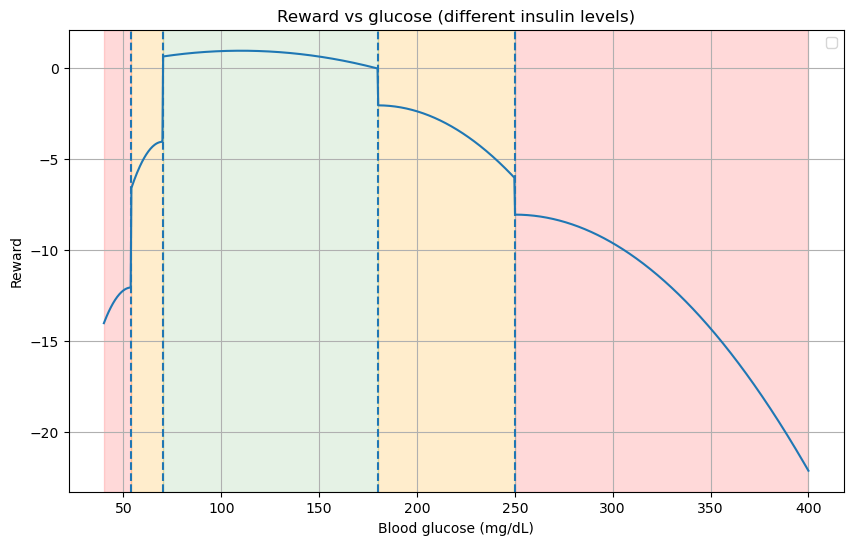

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def glucose_insulin_reward(bg, insulin, raw_insulin, max_insulin_action=6.0):
    if 70 <= bg <= 180:
        r = 1.0 - 0.0002 * (bg - 110)**2
    elif 54 <= bg < 70:
        r = -4.0 - ((70 - bg)/10)**2
    elif bg < 54:
        r = -12.0 - ((54 - bg)/10)**2
    elif 180 < bg <= 250:
        r = -2.0 - ((bg - 180)/35)**2
    else:
        r = -8.0 - ((bg - 250)/40)**2

    excess = max(0.0, raw_insulin - max_insulin_action)
    r -= 2.0 * excess**2
    r -= 0.01 * insulin

    return r


bgs = np.linspace(40, 400, 1000)

plt.figure(figsize=(10, 6))

# Plot curves
for raw in [6]:
    rewards = [
        glucose_insulin_reward(bg, insulin=min(raw, 6), raw_insulin=raw)
        for bg in bgs
    ]
    plt.plot(bgs, rewards)#, label=f"raw insulin = {raw}")

# --- Colored safety regions ---
plt.axvspan(40, 54, color="red", alpha=0.15)
plt.axvspan(250, 400, color="red", alpha=0.15)

plt.axvspan(54, 70, color="orange", alpha=0.2)
plt.axvspan(180, 250, color="orange", alpha=0.2)

plt.axvspan(70, 180, color="green", alpha=0.1)

# Boundaries
for x in [54, 70, 180, 250]:
    plt.axvline(x, linestyle="--")

plt.xlabel("Blood glucose (mg/dL)")
plt.ylabel("Reward")
plt.title("Reward vs glucose (different insulin levels)")

plt.legend()
plt.grid(True)
plt.show()

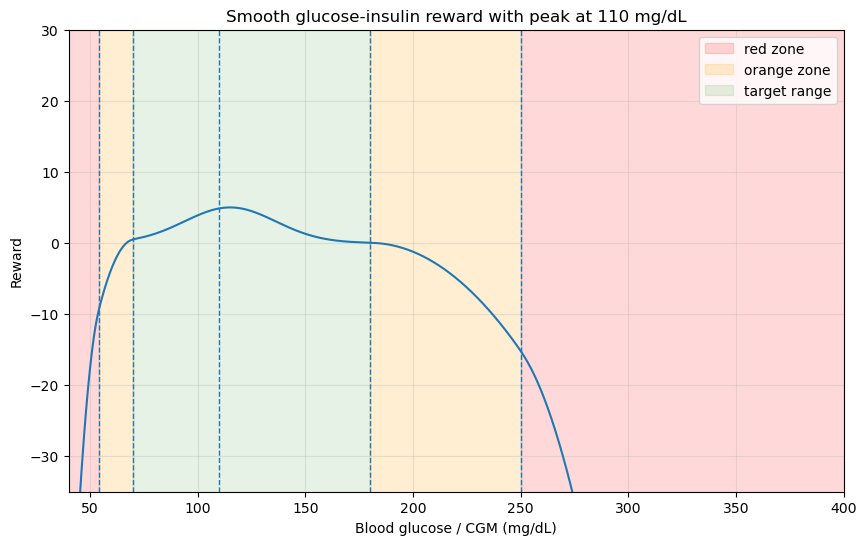

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def softplus(z, sharpness=8.0):
    z = np.asarray(z)
    return np.log1p(np.exp(sharpness * z)) / sharpness


def smooth_glucose_insulin_reward(
    bg: float,
    insulin: float,
    raw_insulin: float,
    max_insulin_action: float = 6.0,
) -> float:
    bg = float(bg)
    insulin = float(insulin)
    raw_insulin = float(raw_insulin)

    # Peak at 110 mg/dL
    target_reward = 5 * np.exp(-((bg - 115.0) / 30.0) ** 2)

    # Smoothly increasing penalties
    low_penalty = 3.0 * softplus((70.0 - bg) / 9.0) ** 2
    severe_low_penalty = 6.0 * softplus((54.0 - bg) / 6.0) ** 2

    high_penalty = 1.5 * softplus((bg - 180.0) / 22.0) ** 2
    severe_high_penalty = 3.0 * softplus((bg - 250.0) / 15.0) ** 2
    

    return float(
        target_reward
        - low_penalty
        - severe_low_penalty
        - high_penalty
        - severe_high_penalty
    )


# Plot
bgs = np.linspace(40, 400, 1200)

plt.figure(figsize=(10, 6))

for raw_insulin in [6]:
    rewards = [
        smooth_glucose_insulin_reward(
            bg=bg,
            insulin=min(raw_insulin, 6),
            raw_insulin=raw_insulin,
        )
        for bg in bgs
    ]
    plt.plot(bgs, rewards)#, label=f"raw insulin = {raw_insulin}")

# Safety regions
plt.axvspan(40, 54, color="red", alpha=0.15, label="red zone")
plt.axvspan(54, 70, color="orange", alpha=0.18, label="orange zone")
plt.axvspan(70, 180, color="green", alpha=0.10, label="target range")
plt.axvspan(180, 250, color="orange", alpha=0.18)
plt.axvspan(250, 400, color="red", alpha=0.15)

for boundary in [54, 70, 110, 180, 250]:
    plt.axvline(boundary, linestyle="--", linewidth=1)

plt.title("Smooth glucose-insulin reward with peak at 110 mg/dL")
plt.xlabel("Blood glucose / CGM (mg/dL)")
plt.ylabel("Reward")
plt.xlim(40, 400)
plt.ylim(-35, 30)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

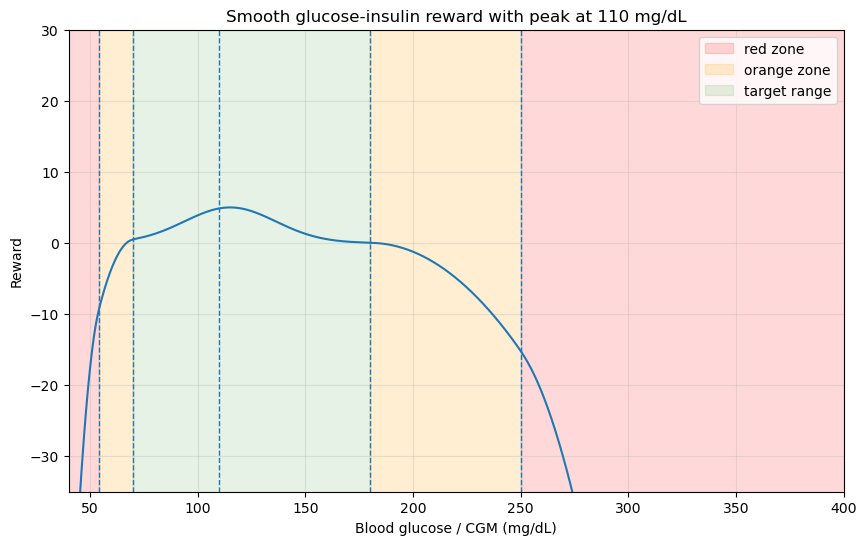

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def softplus(z, sharpness=8.0):
    z = np.asarray(z)
    return np.log1p(np.exp(sharpness * z)) / sharpness


def smooth_glucose_insulin_reward(
    bg: float,
    insulin: float,
    raw_insulin: float,
    max_insulin_action: float = 6.0,
) -> float:
    bg = float(bg)
    insulin = float(insulin)
    raw_insulin = float(raw_insulin)

    # Peak at 110 mg/dL
    target_reward = 5 * np.exp(-((bg - 115.0) / 30.0) ** 2)

    # Smoothly increasing penalties
    low_penalty = 3.0 * softplus((70.0 - bg) / 9.0) ** 2
    severe_low_penalty = 6.0 * softplus((54.0 - bg) / 6.0) ** 2

    high_penalty = 1.5 * softplus((bg - 180.0) / 22.0) ** 2
    severe_high_penalty = 3.0 * softplus((bg - 250.0) / 15.0) ** 2
    

    return float(
        target_reward
        - low_penalty
        - severe_low_penalty
        - high_penalty
        - severe_high_penalty
    )


# Plot
bgs = np.linspace(40, 400, 1200)

plt.figure(figsize=(10, 6))

for raw_insulin in [6]:
    rewards = [
        smooth_glucose_insulin_reward(
            bg=bg,
            insulin=min(raw_insulin, 6),
            raw_insulin=raw_insulin,
        )
        for bg in bgs
    ]
    plt.plot(bgs, rewards)#, label=f"raw insulin = {raw_insulin}")

# Safety regions
plt.axvspan(40, 54, color="red", alpha=0.15, label="red zone")
plt.axvspan(54, 70, color="orange", alpha=0.18, label="orange zone")
plt.axvspan(70, 180, color="green", alpha=0.10, label="target range")
plt.axvspan(180, 250, color="orange", alpha=0.18)
plt.axvspan(250, 400, color="red", alpha=0.15)

for boundary in [54, 70, 110, 180, 250]:
    plt.axvline(boundary, linestyle="--", linewidth=1)

plt.title("Smooth glucose-insulin reward with peak at 110 mg/dL")
plt.xlabel("Blood glucose / CGM (mg/dL)")
plt.ylabel("Reward")
plt.xlim(40, 400)
plt.ylim(-35, 30)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

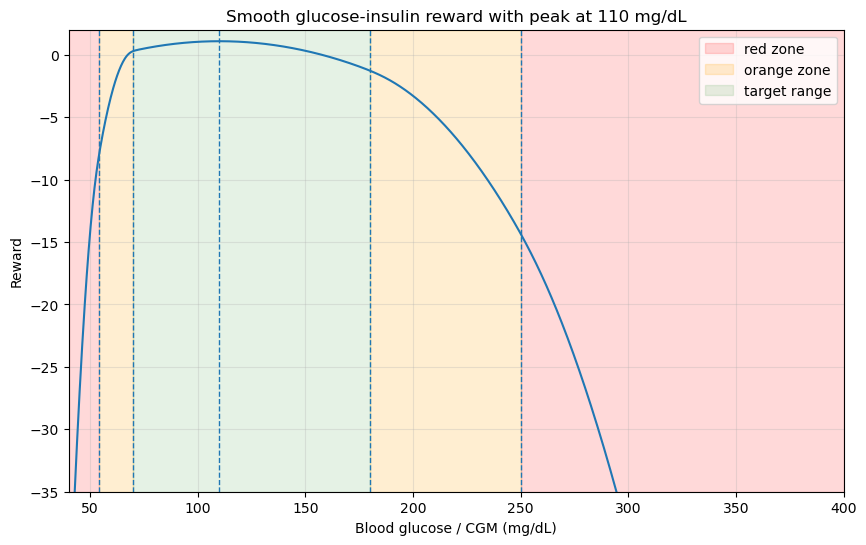

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def softplus(z, sharpness=8.0):
    z = np.asarray(z)
    return np.log1p(np.exp(sharpness * z)) / sharpness


def smooth_glucose_insulin_reward(
    bg: float,
    insulin: float,
    raw_insulin: float,
    max_insulin_action: float = 6.0,
) -> float:
    bg = float(bg)
    insulin = float(insulin)
    raw_insulin = float(raw_insulin)

    # Peak at 110 mg/dL
    target_reward = 1.2*(1.0 - ((bg - 110.0) / 50.0) ** 2)
    #target_reward = 1.5 * np.exp(-((bg - 110.0) / 30.0) ** 2)

    # Smoothly increasing penalties
    low_penalty = 3.0 * softplus((70.0 - bg) / 10.0) ** 2
    severe_low_penalty = 6.0 * softplus((54.0 - bg) / 8.0) ** 2

    high_penalty = 1.5 * softplus((bg - 180.0) / 35.0) ** 2
    severe_high_penalty = 3.0 * softplus((bg - 250.0) / 40.0) ** 2

    insulin_penalty = 0.01 * insulin
    excess_penalty = 2.0 * softplus(
        raw_insulin - max_insulin_action,
        sharpness=4.0,
    ) ** 2

    return float(
        target_reward
        - low_penalty
        - severe_low_penalty
        - high_penalty
        - severe_high_penalty
        - insulin_penalty
        - excess_penalty
    )


# Plot
bgs = np.linspace(40, 400, 1200)

plt.figure(figsize=(10, 6))

for raw_insulin in [6]:
    rewards = [
        smooth_glucose_insulin_reward(
            bg=bg,
            insulin=min(raw_insulin, 6),
            raw_insulin=raw_insulin,
        )
        for bg in bgs
    ]
    plt.plot(bgs, rewards)#, label=f"raw insulin = {raw_insulin}")

# Safety regions
plt.axvspan(40, 54, color="red", alpha=0.15, label="red zone")
plt.axvspan(54, 70, color="orange", alpha=0.18, label="orange zone")
plt.axvspan(70, 180, color="green", alpha=0.10, label="target range")
plt.axvspan(180, 250, color="orange", alpha=0.18)
plt.axvspan(250, 400, color="red", alpha=0.15)

for boundary in [54, 70, 110, 180, 250]:
    plt.axvline(boundary, linestyle="--", linewidth=1)

plt.title("Smooth glucose-insulin reward with peak at 110 mg/dL")
plt.xlabel("Blood glucose / CGM (mg/dL)")
plt.ylabel("Reward")
plt.xlim(40, 400)
plt.ylim(-35, 2)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

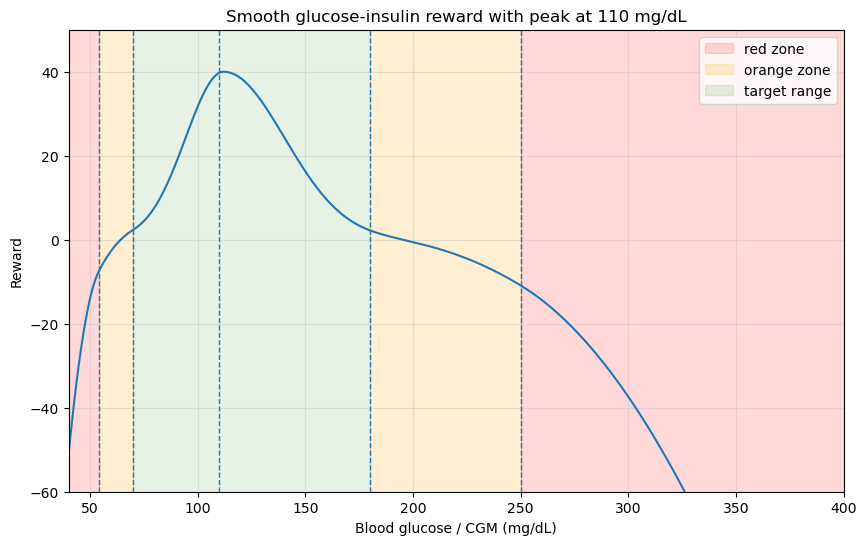

In [22]:
import numpy as np
import matplotlib.pyplot as plt


def softplus(z, sharpness=11.0):
    z = np.asarray(z)
    return np.log1p(np.exp(sharpness * z)) / sharpness


def smooth_glucose_insulin_reward(
    bg: float,
    insulin: float,
    raw_insulin: float,
    max_insulin_action: float = 6.0,
) -> float:
    bg = float(bg)
    insulin = float(insulin)
    raw_insulin = float(raw_insulin)

    # Peak at 110 mg/dL
    # Right-skewed reward curve around target
    target = 112.0

    if bg <= target:
        target_reward = 40 * np.exp(-((bg - target) / 25.0) ** 2)
    else:
        target_reward = 40 * np.exp(-((bg - target) / 40.0) ** 2)

    # Smoothly increasing penalties
    low_penalty = 3.0 * softplus((70.0 - bg) / 10.0) ** 2
    severe_low_penalty = 6.0 * softplus((54.0 - bg) / 7.0) ** 2

    high_penalty = 2 * softplus((bg - 180.0) / 30.0) ** 2
    severe_high_penalty = 0.7 * softplus((bg - 250.0) / 18.0) ** 2
    

    return float(
        target_reward
        - low_penalty
        - severe_low_penalty
        - high_penalty
        - severe_high_penalty
    )


# Plot
bgs = np.linspace(40, 400, 1200)

plt.figure(figsize=(10, 6))

for raw_insulin in [6]:
    rewards = [
        smooth_glucose_insulin_reward(
            bg=bg,
            insulin=min(raw_insulin, 6),
            raw_insulin=raw_insulin,
        )
        for bg in bgs
    ]
    plt.plot(bgs, rewards)#, label=f"raw insulin = {raw_insulin}")

# Safety regions
plt.axvspan(40, 54, color="red", alpha=0.15, label="red zone")
plt.axvspan(54, 70, color="orange", alpha=0.18, label="orange zone")
plt.axvspan(70, 180, color="green", alpha=0.10, label="target range")
plt.axvspan(180, 250, color="orange", alpha=0.18)
plt.axvspan(250, 400, color="red", alpha=0.15)

for boundary in [54, 70, 110, 180, 250]:
    plt.axvline(boundary, linestyle="--", linewidth=1)

plt.title("Smooth glucose-insulin reward with peak at 110 mg/dL")
plt.xlabel("Blood glucose / CGM (mg/dL)")
plt.ylabel("Reward")
plt.xlim(40, 400)
plt.ylim(-60, 50)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()